In [ ]:
"""
Compare FOM analytical data (angle=0 vs Zeng parallel, angle=90 vs Brenner
perpendicular). Data files contain (delta/a, drag-coeff ratio = lambda).
"""
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",

    "font.size": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.0,
})



import pathlib
HERE = pathlib.Path.cwd()
if '__file__' in globals():
    HERE = pathlib.Path(__file__).resolve().parent
# Walk up to find the project root that contains src/wall_corrections.py
p = pathlib.Path(HERE)
ROOT = None
for _ in range(8):
    candidate = p / 'src' / 'wall_corrections.py'
    if candidate.exists():
        ROOT = str(p)
        break
    if p.parent == p:
        break
    p = p.parent
if ROOT is None:
    # Fallback: previous behaviour (keeps compatibility)
    ROOT = os.path.abspath(os.path.join(str(HERE), '..', 'particle_inference'))
# Ensure project root is on sys.path
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.wall_corrections import WallCorrections


class _W(WallCorrections):
    pass


W = _W()

# Locate angle data files: try several candidate directories
angle_files = ("angle-0.txt", "angle-90.txt")
candidate_dirs = [
    pathlib.Path(HERE),
    pathlib.Path(HERE) / 'delta-analytical',
    pathlib.Path(ROOT) / 'plot_3_paper' / 'delta-analytical',
    pathlib.Path(ROOT) / 'data' / 'newtonian' / 'delta-analytical',
    pathlib.Path(ROOT) / 'data' / 'newtonian',
]
_found = None
for d in candidate_dirs:
    if d.exists() and (d / angle_files[0]).exists() and (d / angle_files[1]).exists():
        _found = d
        break
if _found is None:
    raise FileNotFoundError(f"Could not find angle data files in candidate dirs: {candidate_dirs}")

d0 = np.loadtxt(str(_found / "angle-0.txt"))
d90 = np.loadtxt(str(_found / "angle-90.txt"))

delta_par, lam_par_fem = d0[:, 0], d0[:, 1]
delta_perp, lam_perp_fem = d90[:, 0], d90[:, 1]

# Smooth analytical curves
delta_grid = np.logspace(-2, 2, 400)
zeng = W.zeng_parallel(delta_grid)
brenner = W.brenner_perpendicular(delta_grid)

# Evaluated at the FOM points (for tabulated comparison)
zeng_at_par = W.zeng_parallel(delta_par)
brenner_at_perp = W.brenner_perpendicular(delta_perp)

print(f"\n{'delta/a':>10} {'FOM (par)':>14} {'Zeng':>14} {'rel.err %':>12}")
print("-" * 54)
for d, f, z in zip(delta_par, lam_par_fem, zeng_at_par):
    print(f"{d:10.4g} {f:14.6e} {z:14.6e} {100*(z-f)/f:12.3f}")

print(f"\n{'delta/a':>10} {'FOM (perp)':>14} {'Brenner':>14} {'rel.err %':>12}")
print("-" * 54)
for d, f, b in zip(delta_perp, lam_perp_fem, brenner_at_perp):
    print(f"{d:10.4g} {f:14.6e} {b:14.6e} {100*(b-f)/f:12.3f}")

# -----------------------------
# PLOT: PARALLEL & PERPENDICULAR side by side
# -----------------------------
# Note: do NOT pass bbox_inches='tight' to savefig — it crops the canvas to
# the ink and produces PDFs of slightly different sizes. Using
# constrained_layout=True keeps the figure at exactly figsize inches so all
# saved PDFs have identical dimensions when included in LaTeX.
fig, (ax_par, ax_perp) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Parallel
ax_par.plot(delta_grid, zeng, '-', color='tab:blue', label='Zeng et al. (2009)')
ax_par.plot(delta_par, lam_par_fem, 'o', color='k', markersize=12,
            markerfacecolor='white', label=r'FOM ($\theta=0^\circ$)')
ax_par.set_xscale('log')
ax_par.set_xlim(1e-2, 1e2)
ax_par.set_xticks([1e-2, 1e-1, 1e0, 1e1, 1e2])
ax_par.set_ylim(1, 4)
ax_par.set_yticks([1, 2, 3, 4])
ax_par.set_xlabel(r'$\delta/a$')
ax_par.set_ylabel(r'$\lambda_\parallel$')
ax_par.grid(True, alpha=0.3)
ax_par.legend()

# Perpendicular
ax_perp.loglog(delta_grid, brenner, '-', color='tab:red', label='Brenner (1961)')
ax_perp.loglog(delta_perp, lam_perp_fem, 's', color='k', markersize=12,
               markerfacecolor='white', label=r'FOM ($\theta=90^\circ$)')
ax_perp.set_xlim(1e-2, 1e2)
ax_perp.set_xticks([1e-2, 1e-1, 1e0, 1e1, 1e2])
ax_perp.set_ylim(1, 1e2)
ax_perp.set_yticks([1, 1e1, 1e2])
ax_perp.set_xlabel(r'$\delta/a$')
ax_perp.set_ylabel(r'$\lambda_\perp$')
ax_perp.grid(True, alpha=0.3)
ax_perp.legend()

plt.savefig('wall_correction.pdf')
print('Plot saved as wall_correction.pdf')
plt.show()



   delta/a      FOM (par)           Zeng    rel.err %
------------------------------------------------------
      0.01   3.381674e+00   3.419131e+00        1.108
      0.05   2.584458e+00   2.580601e+00       -0.149
       0.1   2.257672e+00   2.235051e+00       -1.002
       0.5   1.595985e+00   1.548628e+00       -2.967
         1   1.383446e+00   1.348669e+00       -2.514
         2   1.228367e+00   1.211486e+00       -1.374
         5   1.106096e+00   1.098988e+00       -0.643
        10   1.061575e+00   1.052387e+00       -0.866
       100   1.019855e+00   1.005191e+00       -1.438

   delta/a     FOM (perp)        Brenner    rel.err %
------------------------------------------------------
      0.01   1.032120e+02   1.018962e+02       -1.275
      0.05   2.160278e+01   2.158582e+01       -0.078
       0.1   1.146165e+01   1.145916e+01       -0.022
       0.5   3.205850e+00   3.205390e+00       -0.014
         1   2.125800e+00   2.125536e+00       -0.012
         2   1.569508e+0

C:\Users\paraj\AppData\Local\Temp\ipykernel_30064\2608604119.py:138: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib

# Use Agg only when not running interactively (Jupyter)
interactive = False
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        interactive = True
except Exception:
    interactive = False
if not interactive:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Ensure the project `src` package is importable when running as a script
import os
import sys
import pathlib

HERE_SCRIPT = Path(__file__).resolve().parent if '__file__' in globals() else Path(os.getcwd())
# Walk up to find the project root that contains src/main.py
p = pathlib.Path(HERE_SCRIPT)
PROJECT_ROOT = None
for _ in range(8):
    candidate = p / 'src' / 'main.py'
    if candidate.exists():
        PROJECT_ROOT = str(p)
        break
    if p.parent == p:
        break
    p = p.parent
if PROJECT_ROOT is None:
    PROJECT_ROOT = str(HERE_SCRIPT.parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.main import InferenceProcedure


# Determine ROOT and DATA_ROOT. Prefer project-root `data/` when available
ROOT = Path(__file__).resolve().parent if '__file__' in globals() else Path(os.getcwd())
candidate_roots = [Path(PROJECT_ROOT) if PROJECT_ROOT is not None else None, ROOT]
DATA_ROOT = None
for r in candidate_roots:
    if r is None:
        continue
    p = Path(r) / "data" / "newtonian" / "f-12pi"
    if p.exists():
        DATA_ROOT = p
        break
if DATA_ROOT is None:
    # Fallback to original relative location (will raise if missing)
    DATA_ROOT = ROOT / "data" / "newtonian" / "f-12pi"

OUT_DIR = ROOT / "plots" / "newtonian_f12pi_delta_overlays"

FORCE = 12.0 * np.pi
ETA = 1.0
T_MAX = 5.8

ANGLES = [0, 45, 90]
DELTAS = [0.1, 0.01, 0.001]


def _delta_label(delta: float) -> str:
    return f"{delta:g}"


def _load_newtonian_file(angle: int, delta: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    path = DATA_ROOT / f"delta-{_delta_label(delta)}-{angle}.txt"
    data = np.loadtxt(path)
    t = data[:, 0]
    x = data[:, 1]
    y = data[:, 2] - data[0, 2]
    keep = t <= T_MAX
    return t[keep], x[keep], y[keep]


def _model_series(
    model: InferenceProcedure,
    angle: int,
    delta: float,
    t: np.ndarray,
) -> np.ndarray:
    model.theta = angle
    if angle == 90:
        return model.model_newtonian(ETA, t, FORCE, delta)
    return model.model_newtonian(ETA, t, FORCE, delta)


def _configure_matplotlib() -> None:
    plt.rcParams.update(
        {
            "text.usetex": True,
            "font.family": "serif",
            "font.size": 30,
            "axes.labelsize": 30,
            "xtick.labelsize": 30,
            "legend.fontsize": 30,
            "lines.linewidth": 2.0,
            "axes.linewidth": 1.0,
        }
    )


def _plot_angle(ax: plt.Axes, model: InferenceProcedure, angle: int, show_legend: bool = False) -> float:
    colors = plt.cm.tab10.colors
    all_y = []

    for idx, delta in enumerate(DELTAS):
        color = colors[idx]
        t, x_obs, y_obs = _load_newtonian_file(angle, delta)
        obs = y_obs if angle == 90 else x_obs
        t_model = np.linspace(0.0, min(T_MAX, float(t.max())), 600)
        pred = _model_series(model, angle, delta, t_model)

        ax.scatter(
            t,
            obs,
            s=16,
            color=color,
            marker="o",
            edgecolors="none",
            alpha=0.9,
            zorder=3,
        )
        ax.plot(t_model, pred, color=color, lw=2.2, zorder=2)
        all_y.extend([obs, pred])

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$y(t)$" if angle == 90 else r"$x(t)$")
    ax.set_title(rf"$\theta = {angle}^\circ$")
    ax.set_xlim(0.0, T_MAX)
    ax.set_xticks([0.0, T_MAX / 2.0, T_MAX])
    ax.grid(alpha=0.3)

    y_max = max(float(np.nanmax(y)) for y in all_y)
    y_top = y_max if y_max > 0 else 1.0
    ax.set_ylim(0.0, y_top)
    ax.set_yticks(np.linspace(0.0, y_top, 3))

    delta_handles = [
        Line2D(
            [0],
            [0],
            color=colors[idx],
            marker="o",
            lw=2.2,
            markersize=5,
            label=rf"$\delta_0/a = {_delta_label(delta)}$",
        )
        for idx, delta in enumerate(DELTAS)
    ]
    if show_legend:
        ax.legend(handles=delta_handles, loc="best", framealpha=0.9)
    return y_top


def main() -> None:
    _configure_matplotlib()
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    model = InferenceProcedure(
        force=FORCE,
        material_model="newtonian",
        boundary_model="bounded",
        theta=45,
        a=1.0,
        t_unload=None,
        sigma_noise_percent=None,
    )

    for angle in ANGLES:
        fig, ax = plt.subplots(figsize=(8, 6.0))
        _plot_angle(ax, model, angle)
        # fig.tight_layout()
        stem = OUT_DIR / f"newtonian_{angle}_delta_overlay"
        fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
        fig.savefig(stem.with_suffix(".png"), bbox_inches="tight")
        plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(24.0, 6.0), constrained_layout=True)
    for idx, (ax, angle) in enumerate(zip(axes, ANGLES)):
        _plot_angle(ax, model, angle, show_legend=(idx == 0))
    for ax in axes:
        ax.set_ylim(0.0, 7.0)
        ax.set_yticks([0.0, 3.5, 7.0])
    # fig.tight_layout(w_pad=2.0)
    stem = OUT_DIR / "newtonian_delta_overlay_all_angles"
    fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), bbox_inches="tight")
    plt.close(fig)

    print(f"Saved plots to: {OUT_DIR}")


if __name__ == "__main__":
    main()


Saved plots to: c:\Users\paraj\Documents\particle_inference_test\plot_3_paper\plots\newtonian_f12pi_delta_overlays


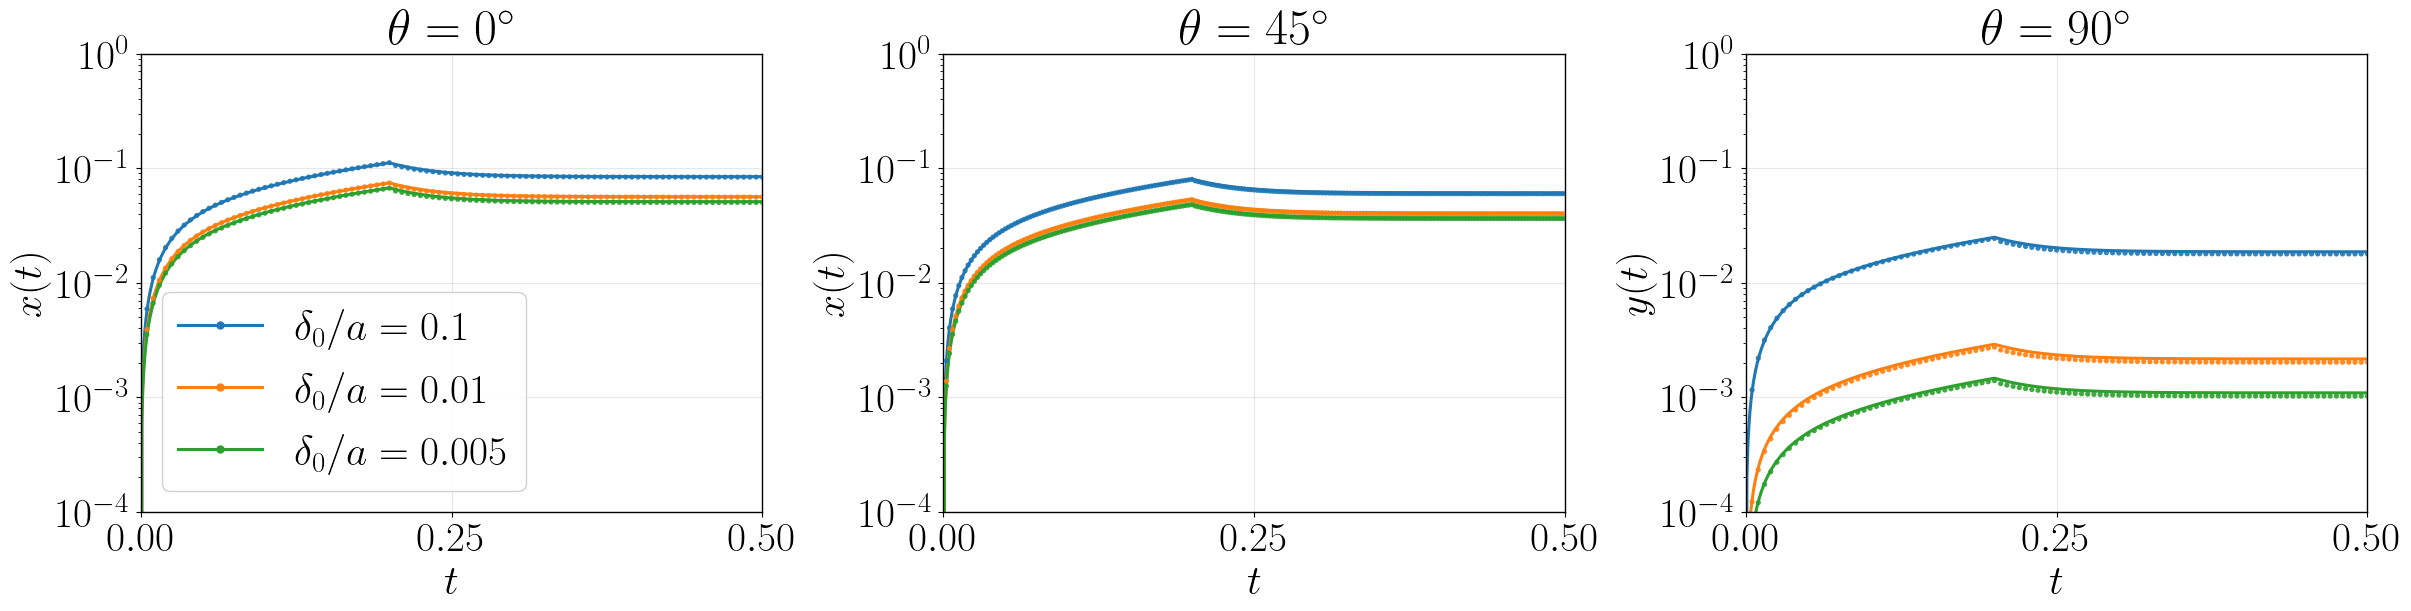

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib

# Use Agg only when not running interactively (Jupyter)
interactive = False
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        interactive = True
except Exception:
    interactive = False
if not interactive:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Ensure the project `src` package is importable when running as a script
import os
import sys
import pathlib

HERE_SCRIPT = Path(__file__).resolve().parent if '__file__' in globals() else Path(os.getcwd())
# Walk up to find the project root that contains src/main.py
p = pathlib.Path(HERE_SCRIPT)
PROJECT_ROOT = None
for _ in range(8):
    candidate = p / 'src' / 'main.py'
    if candidate.exists():
        PROJECT_ROOT = str(p)
        break
    if p.parent == p:
        break
    p = p.parent
if PROJECT_ROOT is None:
    PROJECT_ROOT = str(HERE_SCRIPT.parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.main import InferenceProcedure


ROOT = Path(__file__).resolve().parent if '__file__' in globals() else Path(os.getcwd())
# Prefer data directory at the project root if present
candidate_roots = [Path(PROJECT_ROOT), ROOT]
DATA_ROOT = None
for r in candidate_roots:
    p = Path(r) / "data" / "creep-8pi"
    if p.exists():
        DATA_ROOT = p
        break
if DATA_ROOT is None:
    DATA_ROOT = ROOT / "data" / "creep-8pi"  # fallback; will raise if missing

OUT_DIR = ROOT / "plots" / "creep_8pi_delta_overlays"

FORCE = 8.0 * np.pi
ETA_S = 0.5
ETA_P = 0.9
LAMBDA = 0.1
T_MAX = 0.5

ANGLES = [0, 45, 90]
DELTAS = [0.1, 0.01, 0.005]
CREEP_LOG_YLIM = (1e-4, 1)
CREEP_LOG_YTICKS = [1e-4, 1e-3, 1e-2, 1e-1, 1]


def _delta_label(delta: float) -> str:
    return f"{delta:g}"


def _load_creep_file(angle: int, delta: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    path = DATA_ROOT / f"creep-{angle}" / f"delta-{_delta_label(delta)}-{angle}.out"
    data = np.loadtxt(path)
    t = data[:, 0]
    x = data[:, 1]
    y = data[:, 2] - data[0, 2]
    keep = t <= T_MAX
    return t[keep], x[keep], y[keep]


def _model_series(
    model: InferenceProcedure,
    angle: int,
    delta: float,
    t: np.ndarray,
) -> np.ndarray:
    model.theta = angle
    return model.model_viscoelastic(
        ETA_S,
        ETA_P,
        LAMBDA,
        t,
        FORCE,
        delta,
    )


def _configure_matplotlib() -> None:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 30,
        "axes.labelsize": 30,
        "xtick.labelsize": 30,
        "ytick.labelsize": 30,
        "legend.fontsize": 30,
        "lines.linewidth": 2.0,
        "axes.linewidth": 1.0,
    })


def _plot_angle(
    ax: plt.Axes,
    model: InferenceProcedure,
    angle: int,
    show_ylabel: bool = True,
    show_legend: bool = False,
) -> float:
    colors = plt.cm.tab10.colors
    all_y = []

    for idx, delta in enumerate(DELTAS):
        color = colors[idx]
        t, x_obs, y_obs = _load_creep_file(angle, delta)
        obs = y_obs if angle == 90 else x_obs
        t_model = np.linspace(0.0, min(T_MAX, float(t.max())), 600)
        pred = _model_series(model, angle, delta, t_model)

        ax.scatter(
            t,
            obs,
            s=14,
            color=color,
            marker="o",
            edgecolors="none",
            alpha=0.9,
            zorder=3,
        )
        ax.plot(t_model, pred, color=color, lw=2.2, zorder=2)
        all_y.extend([obs, pred])

    ylabel = r"$y(t)$" if angle == 90 else r"$x(t)$"
    ax.set_xlabel(r"$t$")
    if show_ylabel:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel(ylabel)
    ax.set_title(rf"$\theta = {angle}^\circ$")

    ax.set_xlim(0.0, T_MAX)
    ax.set_xticks([0.0, 0.25, 0.5])
    ax.grid(alpha=0.3)

    y_max = max(float(np.nanmax(y)) for y in all_y)
    y_top = y_max if y_max > 0 else 1.0
    ax.set_ylim(0.0, y_top)
    ax.set_yticks(np.linspace(0.0, y_top, 3))

    delta_handles = [
        Line2D(
            [0],
            [0],
            color=colors[idx],
            marker="o",
            lw=2.2,
            markersize=5,
            label=rf"$\delta_0/a = {_delta_label(delta)}$",
        )
        for idx, delta in enumerate(DELTAS)
    ]
    if show_legend:
        ax.legend(handles=delta_handles, loc="best", framealpha=0.9)
    return y_top


def main() -> None:
    _configure_matplotlib()
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    model = InferenceProcedure(
        force=FORCE,
        material_model="viscoelastic",
        boundary_model="bounded",
        theta=45,
        a=1.0,
        t_unload=0.2,
        sigma_noise_percent=None,
    )

    for angle in ANGLES:
        fig, ax = plt.subplots(figsize=(8.0, 6.0))
        _plot_angle(ax, model, angle)
        # fig.tight_layout()
        stem = OUT_DIR / f"creep_{angle}_delta_overlay"
        fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
        fig.savefig(stem.with_suffix(".png"), bbox_inches="tight")
        plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(24.0, 6.0), constrained_layout=True)
    for idx, (ax, angle) in enumerate(zip(axes, ANGLES)):
        _plot_angle(ax, model, angle, show_ylabel=True, show_legend=(idx == 0))
    for ax in axes:
        ax.set_yscale("log")
        ax.set_ylim(*CREEP_LOG_YLIM)
        ax.set_yticks(CREEP_LOG_YTICKS)
        ax.set_yticklabels([r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"])
    # fig.tight_layout(w_pad=2.0)
    stem = OUT_DIR / "creep_delta_overlay_all_angles"
    fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), bbox_inches="tight")

if __name__ == "__main__":
    main()


In [1]:
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np


HERE = Path.cwd()
if '__file__' in globals():
    HERE = Path(__file__).resolve().parent

# Walk up to find the project root that contains src/wall_corrections.py
p = HERE
ROOT = None
for _ in range(8):
    candidate = p / 'src' / 'wall_corrections.py'
    if candidate.exists():
        ROOT = p
        break
    if p.parent == p:
        break
    p = p.parent
if ROOT is None:
    ROOT = HERE

DATA_FILE = ROOT / "data" / "newtonian" / "f-12pi" / "delta-100-0.txt"
OUT_DIR = Path.cwd() / "plots"
if '__file__' in globals():
    OUT_DIR = Path(__file__).resolve().parent / "plots"

DEFAULT_PERCENTS = (0.5, 2.0, 5.0)
SEED = 42
THIN_FACTOR = 2
FORCE = 12.0 * np.pi
ETA_TRUE = 1.0
A = 1.0

XLIM = (0.0, 5.8)
XTICKS = np.linspace(0.0, 5.8, 3)
YLIM = (0.0, 12.0)
YTICKS = np.linspace(0.0, 12.0, 3)


def configure_matplotlib() -> None:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 30,
        "axes.labelsize": 30,
        "xtick.labelsize": 30,
        "ytick.labelsize": 30,
        "legend.fontsize": 30,
        "lines.linewidth": 2.0,
        "axes.linewidth": 1.0,
    })


def load_clean_data() -> tuple[np.ndarray, np.ndarray]:
    data = np.loadtxt(DATA_FILE)
    data = data[::THIN_FACTOR]
    return data[:, 0], data[:, 1]


def reduced_model(t: np.ndarray) -> np.ndarray:
    mobility = 1.0 / (6.0 * np.pi * ETA_TRUE * A)
    return mobility * FORCE * t


def noisy_observations(x_clean: np.ndarray, pct: float) -> tuple[np.ndarray, float]:
    sigma_noise = (pct / 100.0) * float(np.max(np.abs(x_clean)))
    rng = np.random.default_rng(SEED)
    return x_clean + rng.normal(0.0, sigma_noise, len(x_clean)), sigma_noise


def plot_panel(ax: plt.Axes, t: np.ndarray, x_clean: np.ndarray, pct: float, label: str) -> None:
    x_noisy, _sigma_noise = noisy_observations(x_clean, pct)
    t_model = np.linspace(XLIM[0], XLIM[1], 500)

    ax.scatter(
        t,
        x_noisy,
        color="black",
        s=30,
        marker="o",
        edgecolors="none",
        label="FOM + noise",
        zorder=3,
    )
    ax.plot(t_model, reduced_model(t_model), color="red", label="SAM", zorder=2)

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x(t)$")
    ax.set_xlim(*XLIM)
    ax.set_xticks(XTICKS)
    ax.set_ylim(*YLIM)
    ax.set_yticks(YTICKS)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", framealpha=0.9)


def make_plot(percents: tuple[float, ...]) -> tuple[Path, Path]:
    configure_matplotlib()
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    t, x_clean = load_clean_data()
    fig, axes = plt.subplots(1, len(percents), figsize=(24.0, 6.0), constrained_layout=True)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for idx, (ax, pct) in enumerate(zip(axes.ravel(), percents)):
        label = chr(ord("a") + idx)
        plot_panel(ax, t, x_clean, pct, label)

    # fig.subplots_adjust(left=0.07, right=0.99, top=0.95, bottom=0.28, wspace=0.35)

    stem = OUT_DIR / "newtonian_noise_percent_fixed_axes"
    pdf_path = stem.with_suffix(".pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)
    return pdf_path


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Plot Newtonian synthetic-noise FOM data against the SAM."
    )
    parser.add_argument(
        "--percents",
        nargs="+",
        type=float,
        default=DEFAULT_PERCENTS,
        help="Noise percentages to plot. Default: 0.5 2.0 5.0",
    )
    args, _unknown = parser.parse_known_args()
    return args


def main() -> None:
    args = parse_args()
    percents = tuple(float(pct) for pct in args.percents)
    pdf_path = make_plot(percents)
    print(f"Saved: {pdf_path}")

if __name__ == "__main__":
    main()


FileNotFoundError: c:\Users\paraj\Documents\particle_inference_test\data\newtonian\f-12pi\delta-100-0.txt not found.

In [ ]:
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np


HERE = Path.cwd()
if '__file__' in globals():
    HERE = Path(__file__).resolve().parent

# Walk up to find the project root that contains src/wall_corrections.py
p = HERE
ROOT = None
for _ in range(8):
    candidate = p / "src" / "wall_corrections.py"
    if candidate.exists():
        ROOT = p
        break
    if p.parent == p:
        break
    p = p.parent

if ROOT is None:
    ROOT = HERE

DATA_FILE = ROOT / "data" / "creep-8pi" / "creep-0" / "delta-150-0.out"
PLOTS_DIR = ROOT / "plots"

DEFAULT_PERCENTS = (0.5, 2.0, 5.0)
SEED = 42
THIN_FACTOR = 2

FORCE = 8.0 * np.pi
ETA_S = 0.5
ETA_P_EFF = 0.9
LAMBDA = 0.1
A = 1.0
T_UNLOAD = 0.2

XLIM = (0.0, 0.5)
XTICKS = np.linspace(0.0, 0.5, 3)
YLIM = (0.0, 0.3)
YTICKS = np.linspace(0.0, 0.3, 3)


def configure_matplotlib() -> None:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",

        "font.size": 30,
        "axes.labelsize": 30,
        "xtick.labelsize": 30,
        "ytick.labelsize": 30,
        "legend.fontsize": 30,
        "lines.linewidth": 2.0,
        "axes.linewidth": 1.0,
    })


def load_clean_data() -> tuple[np.ndarray, np.ndarray]:
    data = np.loadtxt(DATA_FILE)
    data = data[::THIN_FACTOR]
    return data[:, 0], data[:, 1]


def analytical_creep_unbounded(t: np.ndarray) -> np.ndarray:
    t = np.asarray(t, dtype=float)
    zeta_s = 6.0 * np.pi * A * ETA_S
    zeta_p = 6.0 * np.pi * A * ETA_P_EFF
    zeta_tot = zeta_s + zeta_p
    tau = LAMBDA * zeta_s / zeta_tot

    coeff_fp = zeta_p * FORCE / zeta_tot
    coeff_x_lin = FORCE / zeta_tot
    coeff_x_exp = FORCE * zeta_p * tau / (zeta_s * zeta_tot)

    x = np.empty_like(t, dtype=float)
    loading = t <= T_UNLOAD
    exp_loading = np.exp(-t[loading] / tau)
    x[loading] = coeff_x_lin * t[loading] + coeff_x_exp * (1.0 - exp_loading)

    exp_unload = np.exp(-T_UNLOAD / tau)
    fp_unload = coeff_fp * (1.0 - exp_unload)
    x_unload = coeff_x_lin * T_UNLOAD + coeff_x_exp * (1.0 - exp_unload)

    recovery = ~loading
    dt_recovery = t[recovery] - T_UNLOAD
    exp_recovery = np.exp(-dt_recovery / tau)
    x[recovery] = x_unload - (fp_unload * tau / zeta_s) * (1.0 - exp_recovery)
    return x


def load_reduced_model() -> tuple[np.ndarray, np.ndarray]:
    candidates = sorted(PLOTS_DIR.glob("creep_unbounded_F8pi_delta150_sigexp*_angle0/analytical_model.txt"))
    if candidates:
        arrays = []
        for candidate in candidates:
            try:
                arr = np.loadtxt(candidate)
            except OSError:
                continue
            if arr.ndim == 2 and arr.shape[1] >= 2:
                arrays.append(arr)
        if arrays:
            model = max(arrays, key=lambda arr: arr.shape[0])
            return model[:, 0], model[:, 1]

    t_model = np.linspace(XLIM[0], XLIM[1], 500)
    return t_model, analytical_creep_unbounded(t_model)


def noisy_observations(x_clean: np.ndarray, pct: float) -> tuple[np.ndarray, float]:
    sigma_noise = (pct / 100.0) * float(np.max(np.abs(x_clean)))
    rng = np.random.default_rng(SEED)
    return x_clean + rng.normal(0.0, sigma_noise, len(x_clean)), sigma_noise


def plot_panel(
    ax: plt.Axes,
    t_data: np.ndarray,
    x_clean: np.ndarray,
    t_model: np.ndarray,
    x_model: np.ndarray,
    pct: float,
) -> None:
    x_noisy, _sigma_noise = noisy_observations(x_clean, pct)

    ax.scatter(
        t_data,
        x_noisy,
        color="black",
        s=30,
        marker="o",
        edgecolors="none",
        label="FOM +  noise",
        zorder=3,
    )
    ax.plot(t_model, x_model, color="red", label="SAM", zorder=2)

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x(t)$")
    ax.set_xlim(*XLIM)
    ax.set_xticks(XTICKS)
    ax.set_ylim(*YLIM)
    ax.set_yticks(YTICKS)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", framealpha=0.9)


def make_plot(percents: tuple[float, ...]) -> tuple[Path, Path]:
    configure_matplotlib()
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    t_data, x_clean = load_clean_data()
    t_model, x_model = load_reduced_model()

    fig, axes = plt.subplots(1, len(percents), figsize=(24.0, 6.0), constrained_layout=True)

    # Normalize axes to an iterable list for len==1 or len>1
    if isinstance(axes, np.ndarray):
        axes_iter = axes.ravel()
    else:
        axes_iter = [axes]

    for ax, pct in zip(axes_iter, percents):
        plot_panel(ax, t_data, x_clean, t_model, x_model, pct)

    # fig.subplots_adjust(left=0.065, right=0.995, top=0.98, bottom=0.22, wspace=0.42)

    stem = PLOTS_DIR / "creep_unbounded_noise_percent_fixed_axes"
    pdf_path = stem.with_suffix(".pdf")
    png_path = stem.with_suffix(".png")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    plt.close(fig)
    return pdf_path, png_path


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Plot creep-unbounded synthetic-noise FOM data against the SAM."
    )
    parser.add_argument(
        "--percents",
        nargs="+",
        type=float,
        default=DEFAULT_PERCENTS,
        help="Noise percentages to plot. Default: 0.5 2.0 5.0",
    )
    args, _unknown = parser.parse_known_args()
    return args


def main() -> None:
    args = parse_args()
    percents = tuple(float(pct) for pct in args.percents)
    pdf_path, png_path = make_plot(percents)
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

if __name__ == "__main__":
    main()


Saved: c:\Users\paraj\Documents\particle_inference_test\plots\creep_unbounded_noise_percent_fixed_axes.pdf
Saved: c:\Users\paraj\Documents\particle_inference_test\plots\creep_unbounded_noise_percent_fixed_axes.png


wrote C:\Users\paraj\Documents\particle_inference_test\plots\angled_delta_t_vs_x.png


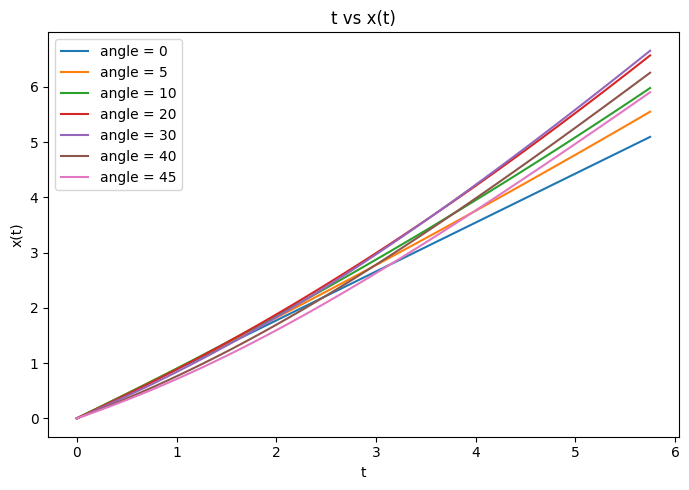

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_dir = Path(r"C:\Users\paraj\Documents\particle_inference_test\data\newtonian\angled_delta")
out_path = Path(r"C:\Users\paraj\Documents\particle_inference_test\plots\angled_delta_t_vs_x.png")

files = sorted(data_dir.glob("*.txt"), key=lambda p: int(re.search(r"(\d+)", p.stem).group(1)))

fig, ax = plt.subplots(figsize=(7, 5))
for f in files:
    angle = int(re.search(r"(\d+)", f.stem).group(1))
    d = np.loadtxt(f)
    ax.plot(d[:, 0], d[:, 1], label=f"angle = {angle}")

ax.set_xlabel("t")
ax.set_ylabel("x(t)")
ax.set_title("t vs x(t)")
ax.legend()
fig.tight_layout()
fig.savefig(out_path, dpi=150)
print(f"wrote {out_path}")

In [8]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


values = np.array(
    [
        1.5456e01,
        1.7149e01,
        1.7453e01,
        2.1560e01,
        1.6598e01,
        1.4354e01,
        2.0060e01,
        1.6660e01,
        2.0331e01,
        1.8179e01,
        2.3802e01,
        1.8448e01,
        1.6052e01,
        1.6389e01,
        1.6111e01,
        1.8252e01,
        1.7960e01,
        1.5990e01,
        1.9692e01,
        1.8119e01,
        1.5340e01,
        1.5332e01,
        1.6182e01,
        1.9146e01,
        1.6297e01,
        1.4711e01,
        1.6169e01,
        1.7638e01,
        1.7575e01,
        1.4790e01,
        2.0669e01,
        1.6892e01,
        1.5134e01,
        1.4624e01,
        1.6614e01,
        2.3050e01,
        1.6994e01,
        1.7578e01,
        1.8347e01,
        1.5969e01,
    ]
)

bulk_g = 17.14
mean = values.mean()
stderr = values.std(ddof=1) / math.sqrt(values.size)
ci95_half_width = 2 * stderr

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",

    "font.size": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 26,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.0,
})

output_dir = Path.cwd()
if '__file__' in globals():
    output_dir = Path(__file__).resolve().parent

fig, ax = plt.subplots(figsize=(8, 6))

bins = np.histogram_bin_edges(values, bins="sturges")
ax.hist(
    values,
    bins=bins,
    color="#9FBAD6",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.68,
    # label=r"Values",
    zorder=1,
)

ax.axvspan(
    mean - ci95_half_width,
    mean + ci95_half_width,
    facecolor="#F4A261",
    edgecolor="#8C510A",
    linewidth=1.4,
    hatch="//",
    alpha=0.42,
    # label=rf"95\% CI $=\pm {ci95_half_width:.2f}$",
    zorder=2,
)
ax.axvline(
    mean,
    color="#1B5E20",
    linestyle="-",
    linewidth=2.6,
    label=rf"$\bar{{G}}_{{\rm loc}}={mean:.2f}$",
    zorder=4,
)
ax.axvline(
    bulk_g,
    color="red",
    linestyle=":",
    linewidth=3.0,
    label=rf"$G_{{\rm bulk}}={bulk_g:.2f}$",
    zorder=4,
)

ax.set_xlabel(r"$G$")
ax.tick_params(axis="both", which="major", labelsize=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(framealpha=0.93)

fig.savefig(output_dir / "values_histogram_40.png", dpi=300, bbox_inches="tight")
fig.savefig(output_dir / "values_histogram_40.pdf", bbox_inches="tight")

print(f"n = {values.size}")
print(f"mean = {mean:.6f}")
print(f"stderr = {stderr:.6f}")
print(f"95_ci_half_width = {ci95_half_width:.6f}")
print(f"bulk_g = {bulk_g:.6f}")
print(f"saved_png = {output_dir / 'values_histogram_40.png'}")
print(f"saved_pdf = {output_dir / 'values_histogram_40.pdf'}")


n = 40
mean = 17.441650
stderr = 0.351359
95_ci_half_width = 0.702718
bulk_g = 17.140000
saved_png = c:\Users\paraj\Documents\particle_inference_test\plot_3_paper\values_histogram_40.png
saved_pdf = c:\Users\paraj\Documents\particle_inference_test\plot_3_paper\values_histogram_40.pdf
